In [1]:
import pandas as pd
df=pd.read_csv("data/DB_final.csv")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


if df.isnull().sum().sum() > 0:
    raise ValueError(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


X = df.drop(columns=['Text', 'Writer', 'is_AI'])
y = df['Writer']


le = LabelEncoder()                                        
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test= train_test_split(
    X, 
    y_encoded, 
    test_size=0.20, 
    random_state=999, 
    stratify=y_encoded   # same class distribution in train and test
)


print(f"X Train/Test: {X_train.shape} , {X_test.shape}")
print(f"y Train/Test: {len(y_train)} , {len(y_test)}")
print("Classes identified:", le.classes_)

X Train/Test: (40944, 16) , (10237, 16)
y Train/Test: 40944 , 10237
Classes identified: ['GPT_4-o' 'Human_story' 'accounts/yi-01-ai/models/yi-large' 'gemma-2-9b'
 'llama-8B' 'mistral-7B' 'qwen-2-72B']


In [ ]:
import xgboost as xgb
import torch

xgb_classifier = xgb.XGBClassifier(
    objective='multi:softprob',  # multiclass classification
    tree_method='hist',          
    device='cuda' if torch.cuda.is_available() else 'cpu',
    eval_metric=['mlogloss','merror'],
    n_estimators=2000,
    early_stopping_rounds=100,
    learning_rate=0.05,
    max_depth=10,
    random_state=999
)

print("Starting training on GPU...")
xgb_classifier.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
print("Training completed!")

Starting training on GPU...
[0]	validation_0-mlogloss:1.87340	validation_0-merror:0.38478
[100]	validation_0-mlogloss:0.80738	validation_0-merror:0.29833
[200]	validation_0-mlogloss:0.76251	validation_0-merror:0.28690
[300]	validation_0-mlogloss:0.76230	validation_0-merror:0.28241
[400]	validation_0-mlogloss:0.77123	validation_0-merror:0.28084
[491]	validation_0-mlogloss:0.78148	validation_0-merror:0.28231
Training completed!


/home/basel/Work/python/ai_text_detection/.venv/lib/python3.11/site-packages/xgboost/core.py:774: UserWarning: [04:37:27] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Classification Report:
                                   precision    recall  f1-score   support

                          GPT_4-o       0.86      0.86      0.86      1465
                      Human_story       0.93      0.94      0.94      1459
accounts/yi-01-ai/models/yi-large       0.70      0.73      0.72      1464
                       gemma-2-9b       0.76      0.82      0.79      1462
                         llama-8B       0.60      0.61      0.60      1461
                       mistral-7B       0.51      0.48      0.49      1463
                       qwen-2-72B       0.66      0.61      0.63      1463

                         accuracy                           0.72     10237
                        macro avg       0.72      0.72      0.72     10237
                     weighted avg       0.72      0.72      0.72     10237



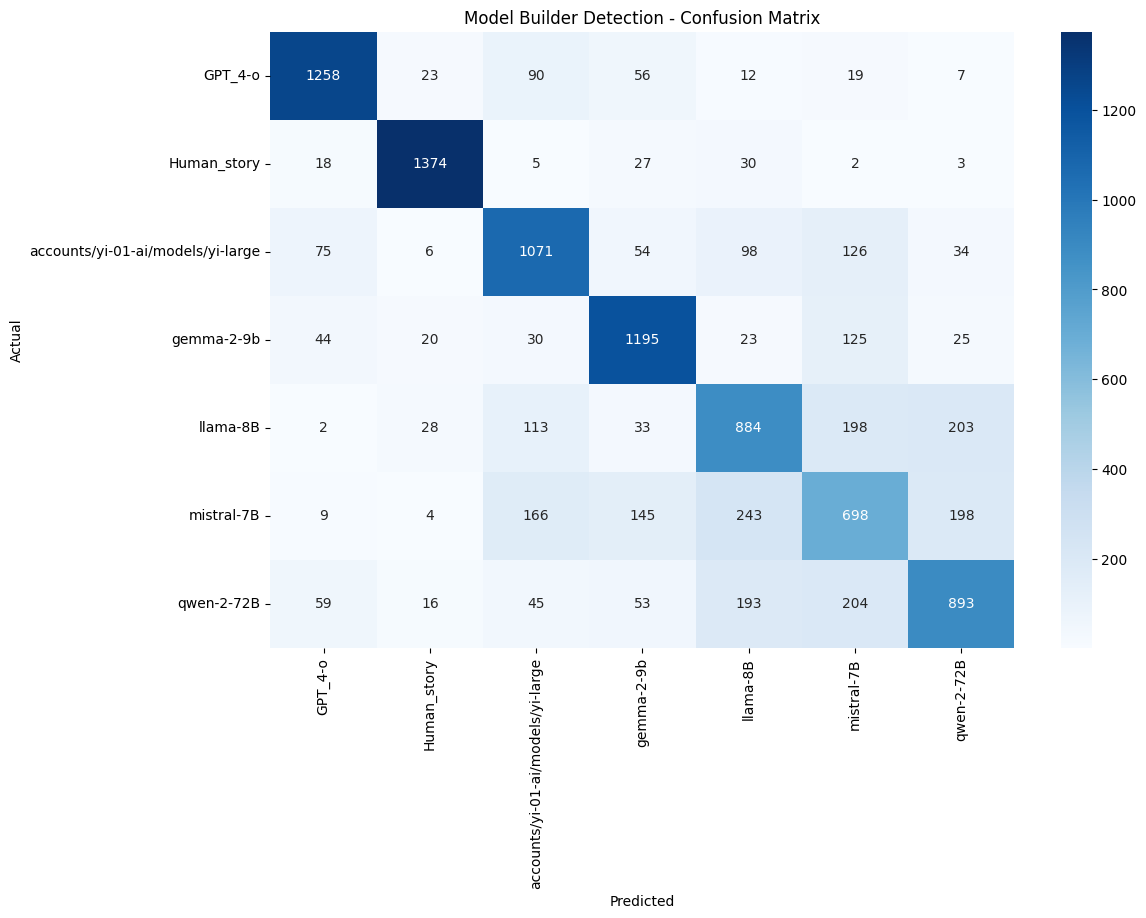

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = xgb_classifier.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model Builder Detection - Confusion Matrix')
plt.show()

/tmp/ipykernel_123520/897342157.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


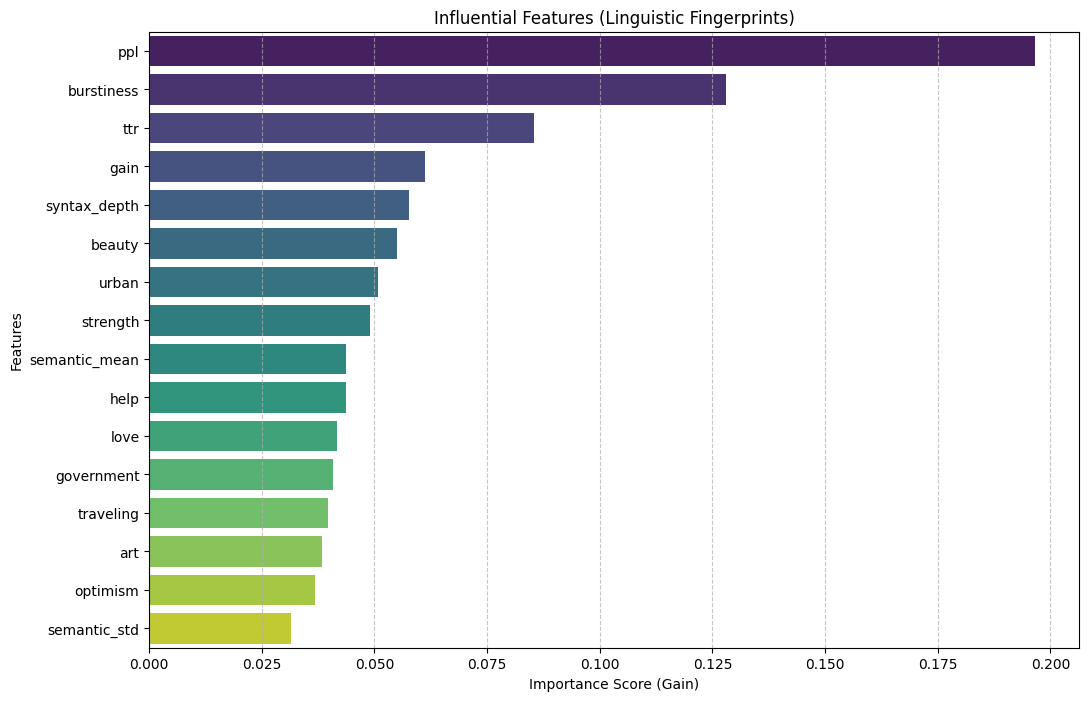

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = xgb_classifier.feature_importances_
feature_names = X.columns 


feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Influential Features (Linguistic Fingerprints)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



In [ ]:
# Save the trained model
import joblib

joblib.dump(xgb_classifier, 'models/xgb_classifier.pkl')


['models/xgb_classifier.pkl']